In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [8]:
import os
base = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS'
print(os.listdir(base))

['Datasets', 'Checkpoints', 'Notebooks', 'Outputs']


In [9]:
import os

# ── Root ──────────────────────────────────────────────────
base_output  = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs'
wesad_path   = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/WESAD'

# ── WESAD subfolders ──────────────────────────────────────
wesad_per_subject = f'{base_output}/WESAD/per_subject'
wesad_combined    = f'{base_output}/WESAD/combined'
wesad_plots       = f'{base_output}/WESAD/plots'
wesad_reports     = f'{base_output}/WESAD/reports'

# Create all folders
for folder in [wesad_per_subject, wesad_combined, wesad_plots, wesad_reports]:
    os.makedirs(folder, exist_ok=True)

print("Folder structure created:")
print(f"  {base_output}/WESAD/")
print(f"    per_subject/   ← individual subject files")
print(f"    combined/      ← merged dataset arrays")
print(f"    plots/         ← all visualizations")
print(f"    reports/       ← quality report and preprocessing report")
print(f"  feature_names.json → root Outputs folder")

Folder structure created:
  /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/WESAD/
    per_subject/   ← individual subject files
    combined/      ← merged dataset arrays
    plots/         ← all visualizations
    reports/       ← quality report and preprocessing report
  feature_names.json → root Outputs folder


In [10]:
# Look inside subject S2
s2_path = os.path.join(wesad_path, 'S2')
print(os.listdir(s2_path))

['S2.pkl', 'S2_readme.txt', 'S2_E4_Data.zip', 'S2_quest.csv', 'S2_respiban.txt']


In [11]:
import pickle

s2_pkl_path = '/content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Datasets/WESAD/S2/S2.pkl'

with open(s2_pkl_path, 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Top level keys:", data.keys())
print("Signal keys:", data['signal'].keys())
print("Chest keys:", data['signal']['chest'].keys())

Top level keys: dict_keys(['signal', 'label', 'subject'])
Signal keys: dict_keys(['chest', 'wrist'])
Chest keys: dict_keys(['ACC', 'ECG', 'EMG', 'EDA', 'Temp', 'Resp'])


In [12]:
import numpy as np

chest = data['signal']['chest']
labels = data['label']

print("ECG shape:    ", chest['ECG'].shape)
print("Resp shape:   ", chest['Resp'].shape)
print("Temp shape:   ", chest['Temp'].shape)
print("ACC shape:    ", chest['ACC'].shape)
print("Labels shape: ", labels.shape)
print("Unique labels:", np.unique(labels))

ECG shape:     (4255300, 1)
Resp shape:    (4255300, 1)
Temp shape:    (4255300, 1)
ACC shape:     (4255300, 3)
Labels shape:  (4255300,)
Unique labels: [0 1 2 3 4 6 7]


In [13]:
baseline_count = np.sum(labels == 1)
stress_count = np.sum(labels == 2)

print(f"Baseline samples: {baseline_count} ({baseline_count/700:.0f} seconds)")
print(f"Stress samples:   {stress_count} ({stress_count/700:.0f} seconds)")

Baseline samples: 800800 (1144 seconds)
Stress samples:   430500 (615 seconds)


In [14]:
import pickle
import numpy as np

subjects = ['S2','S3','S4','S5','S6','S7','S8','S9','S10','S11','S13','S14','S15','S16','S17']

for sid in subjects:
    pkl_path = f'{wesad_path}/{sid}/{sid}.pkl'
    try:
        with open(pkl_path, 'rb') as f:
            d = pickle.load(f, encoding='latin1')
        labels = d['label']
        b = np.sum(labels == 1)
        s = np.sum(labels == 2)
        print(f"{sid} | Baseline: {b/700:.0f}s | Stress: {s/700:.0f}s")
    except:
        print(f"{sid} | NOT FOUND")

S2 | Baseline: 1144s | Stress: 615s
S3 | Baseline: 1140s | Stress: 640s
S4 | Baseline: 1158s | Stress: 635s
S5 | Baseline: 1198s | Stress: 645s
S6 | Baseline: 1180s | Stress: 650s
S7 | Baseline: 1186s | Stress: 640s
S8 | Baseline: 1169s | Stress: 670s
S9 | Baseline: 1180s | Stress: 645s
S10 | Baseline: 1180s | Stress: 725s
S11 | Baseline: 1180s | Stress: 680s
S13 | Baseline: 1180s | Stress: 664s
S14 | Baseline: 1180s | Stress: 675s
S15 | Baseline: 1175s | Stress: 686s
S16 | Baseline: 1180s | Stress: 673s
S17 | Baseline: 1181s | Stress: 723s


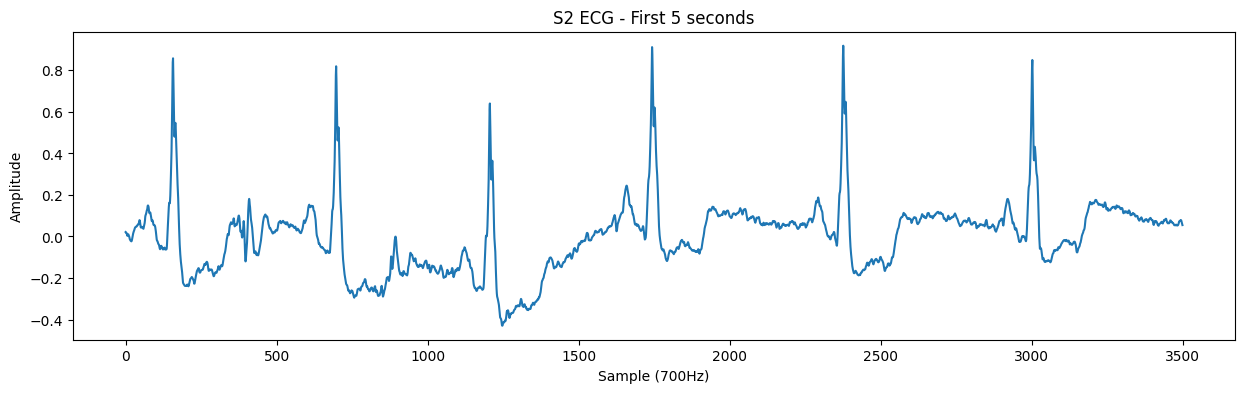

In [15]:
import matplotlib.pyplot as plt

chest = data['signal']['chest']
ecg = chest['ECG'].flatten()
labels = data['label'].flatten()

# Plot first 5 seconds of baseline ECG (700Hz x 5 = 3500 samples)
plt.figure(figsize=(15,4))
plt.plot(ecg[:3500])
plt.title('S2 ECG - First 5 seconds')
plt.xlabel('Sample (700Hz)')
plt.ylabel('Amplitude')
plt.show()

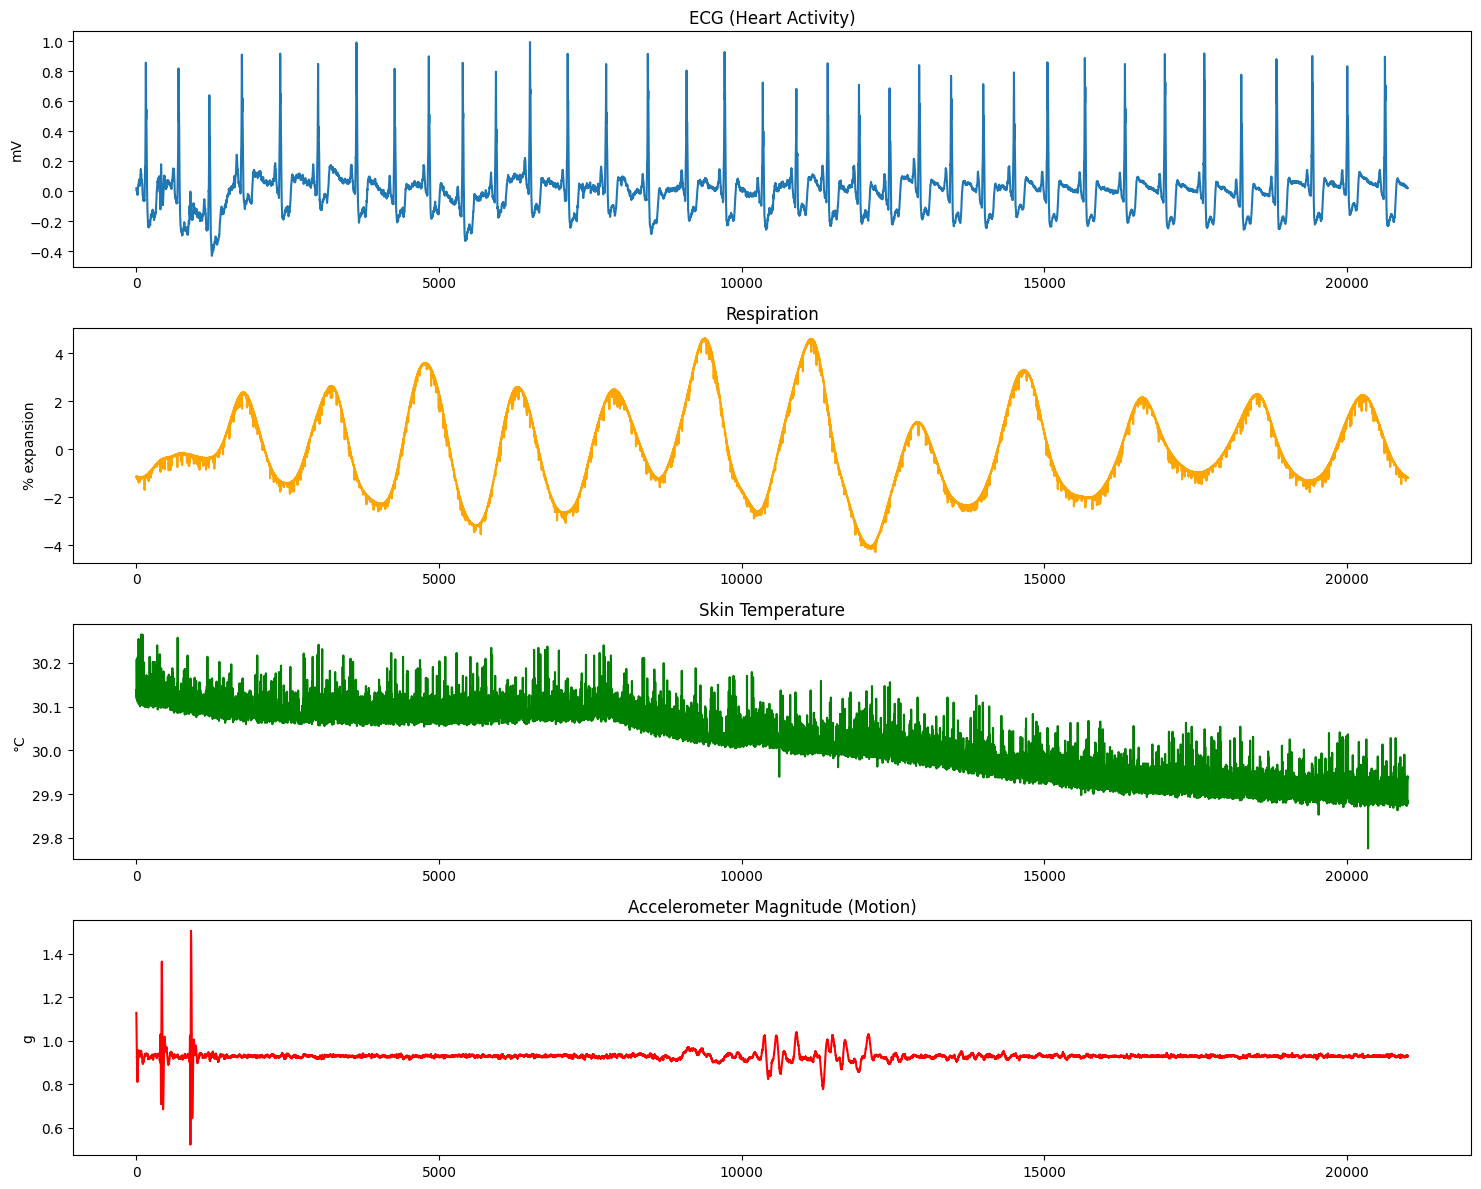

In [16]:
fig, axes = plt.subplots(4, 1, figsize=(15, 12))

ecg = chest['ECG'].flatten()
resp = chest['Resp'].flatten()
temp = chest['Temp'].flatten()
acc = chest['ACC']
acc_mag = np.sqrt(acc[:,0]**2 + acc[:,1]**2 + acc[:,2]**2)

# Plot 30 seconds of data (700 x 30 = 21000 samples)
samples = 21000

axes[0].plot(ecg[:samples])
axes[0].set_title('ECG (Heart Activity)')
axes[0].set_ylabel('mV')

axes[1].plot(resp[:samples], color='orange')
axes[1].set_title('Respiration')
axes[1].set_ylabel('% expansion')

axes[2].plot(temp[:samples], color='green')
axes[2].set_title('Skin Temperature')
axes[2].set_ylabel('°C')

axes[3].plot(acc_mag[:samples], color='red')
axes[3].set_title('Accelerometer Magnitude (Motion)')
axes[3].set_ylabel('g')

plt.tight_layout()
plt.show()

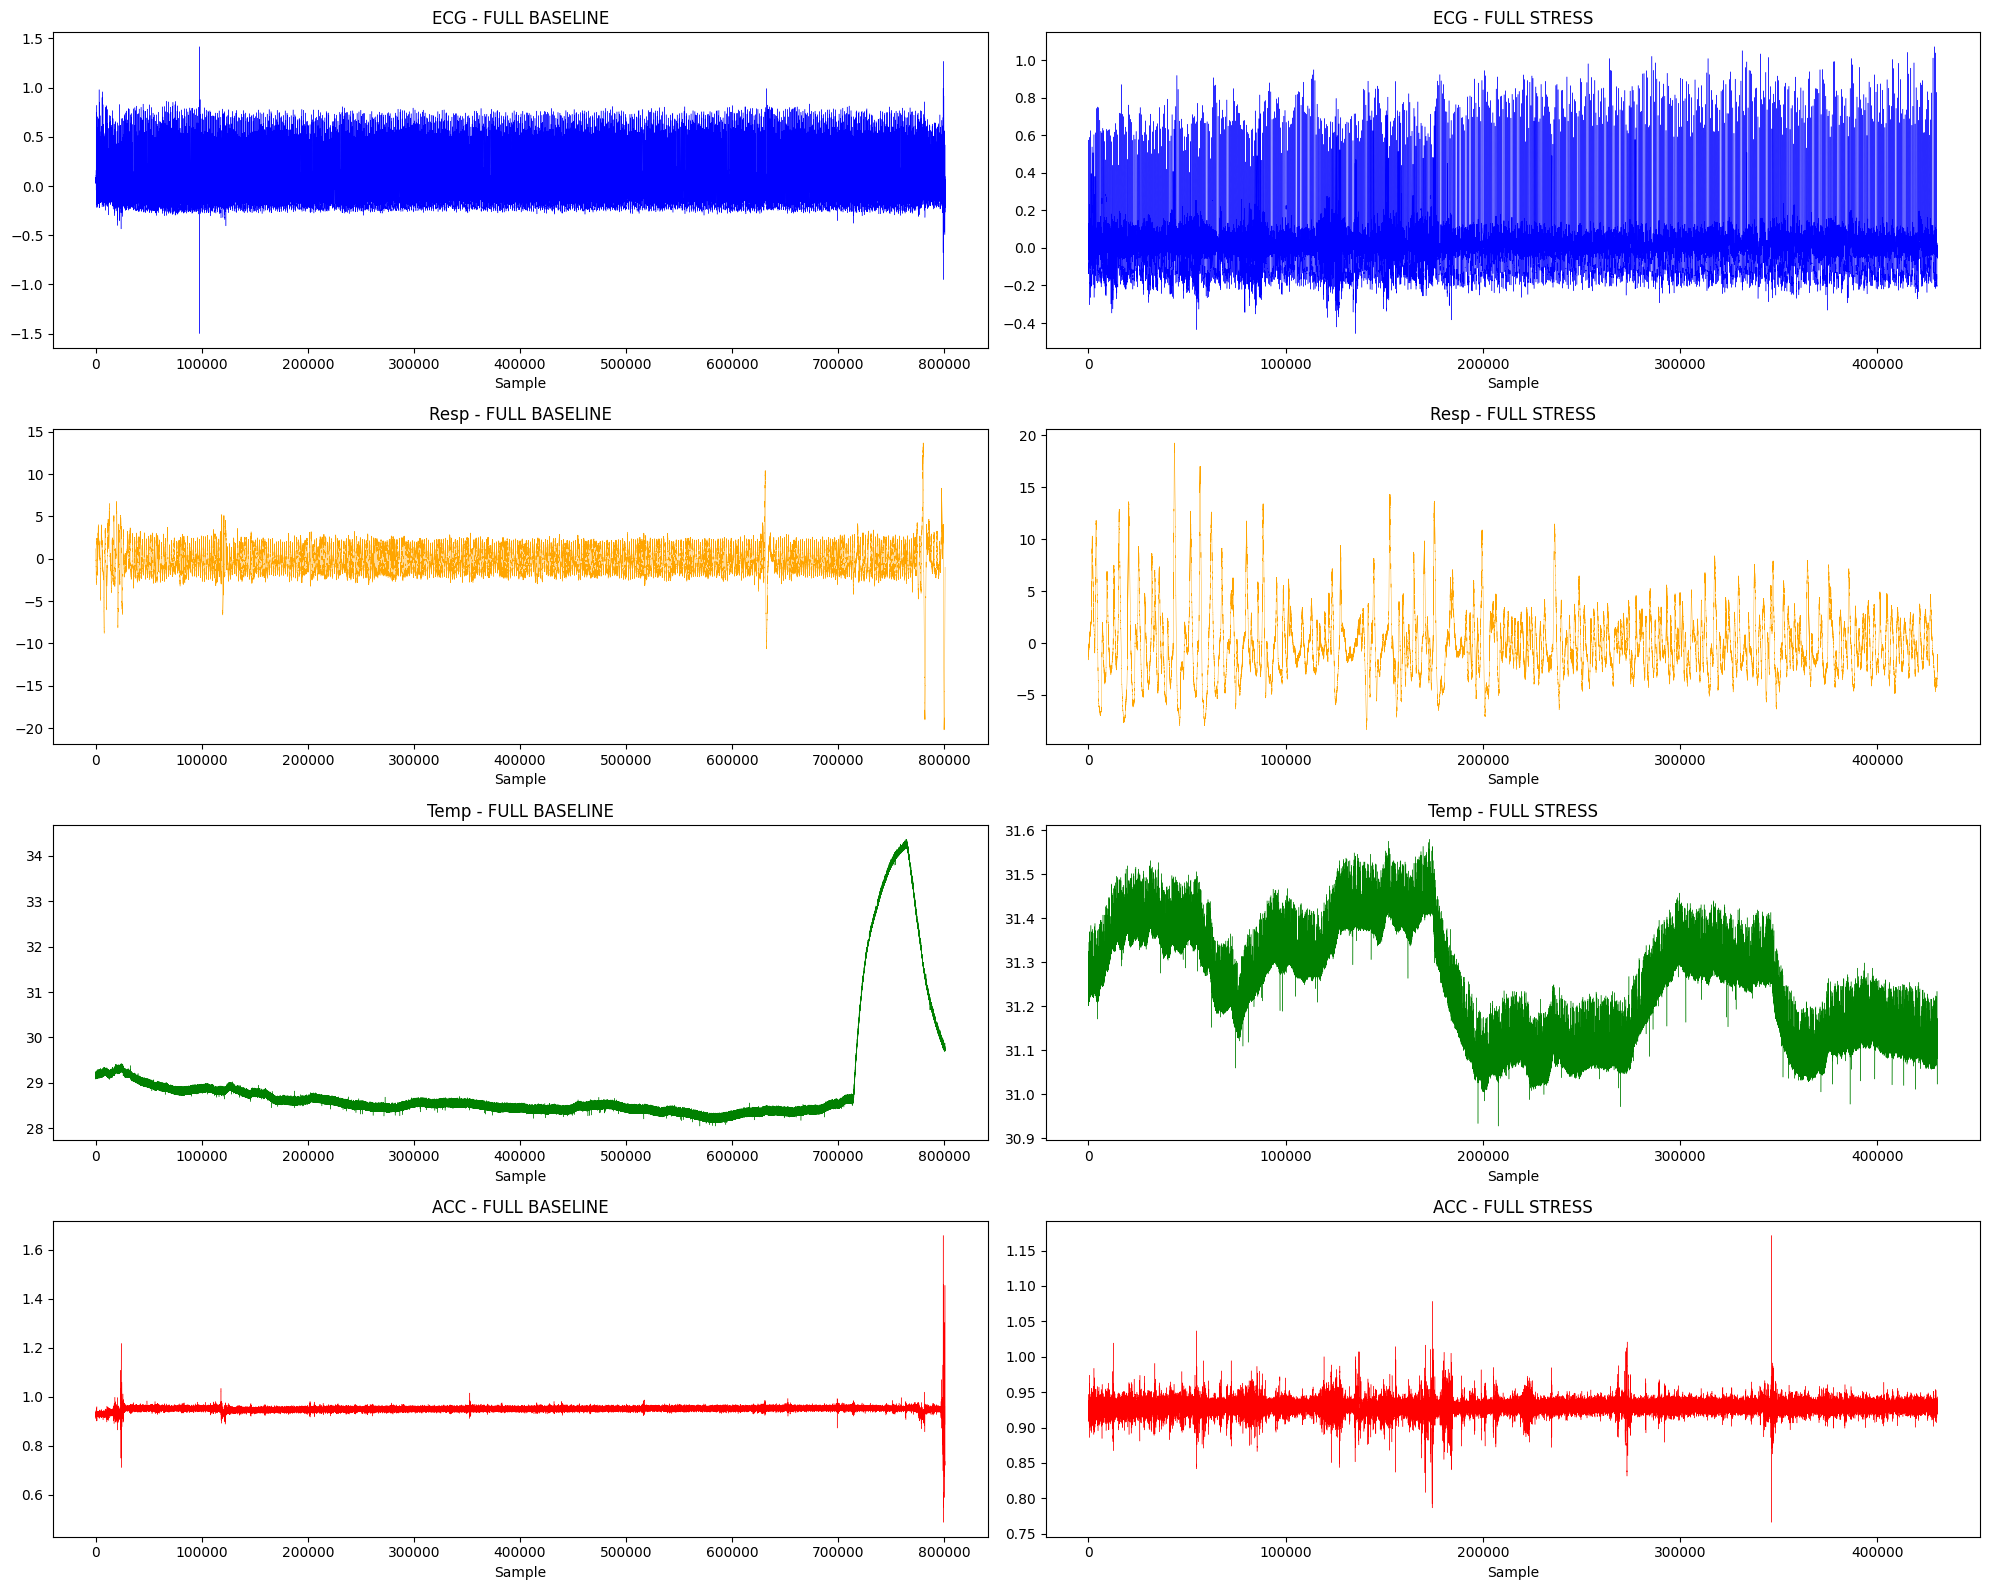

In [17]:
fig, axes = plt.subplots(4, 2, figsize=(20, 16))

signals = {
    'ECG': ecg,
    'Resp': resp,
    'Temp': temp,
    'ACC': acc_mag
}

colors = ['blue', 'orange', 'green', 'red']
names = ['ECG', 'Resp', 'Temp', 'ACC']

baseline_idx = np.where(labels == 1)[0]
stress_idx   = np.where(labels == 2)[0]

raw_signals = [ecg, resp, temp, acc_mag]

for i, (name, signal, color) in enumerate(zip(names, raw_signals, colors)):
    # Baseline - full
    axes[i][0].plot(signal[baseline_idx],
                    color=color, linewidth=0.3)
    axes[i][0].set_title(f'{name} - FULL BASELINE')
    axes[i][0].set_xlabel('Sample')

    # Stress - full
    axes[i][1].plot(signal[stress_idx],
                    color=color, linewidth=0.3)
    axes[i][1].set_title(f'{name} - FULL STRESS')
    axes[i][1].set_xlabel('Sample')

plt.tight_layout()
plt.show()

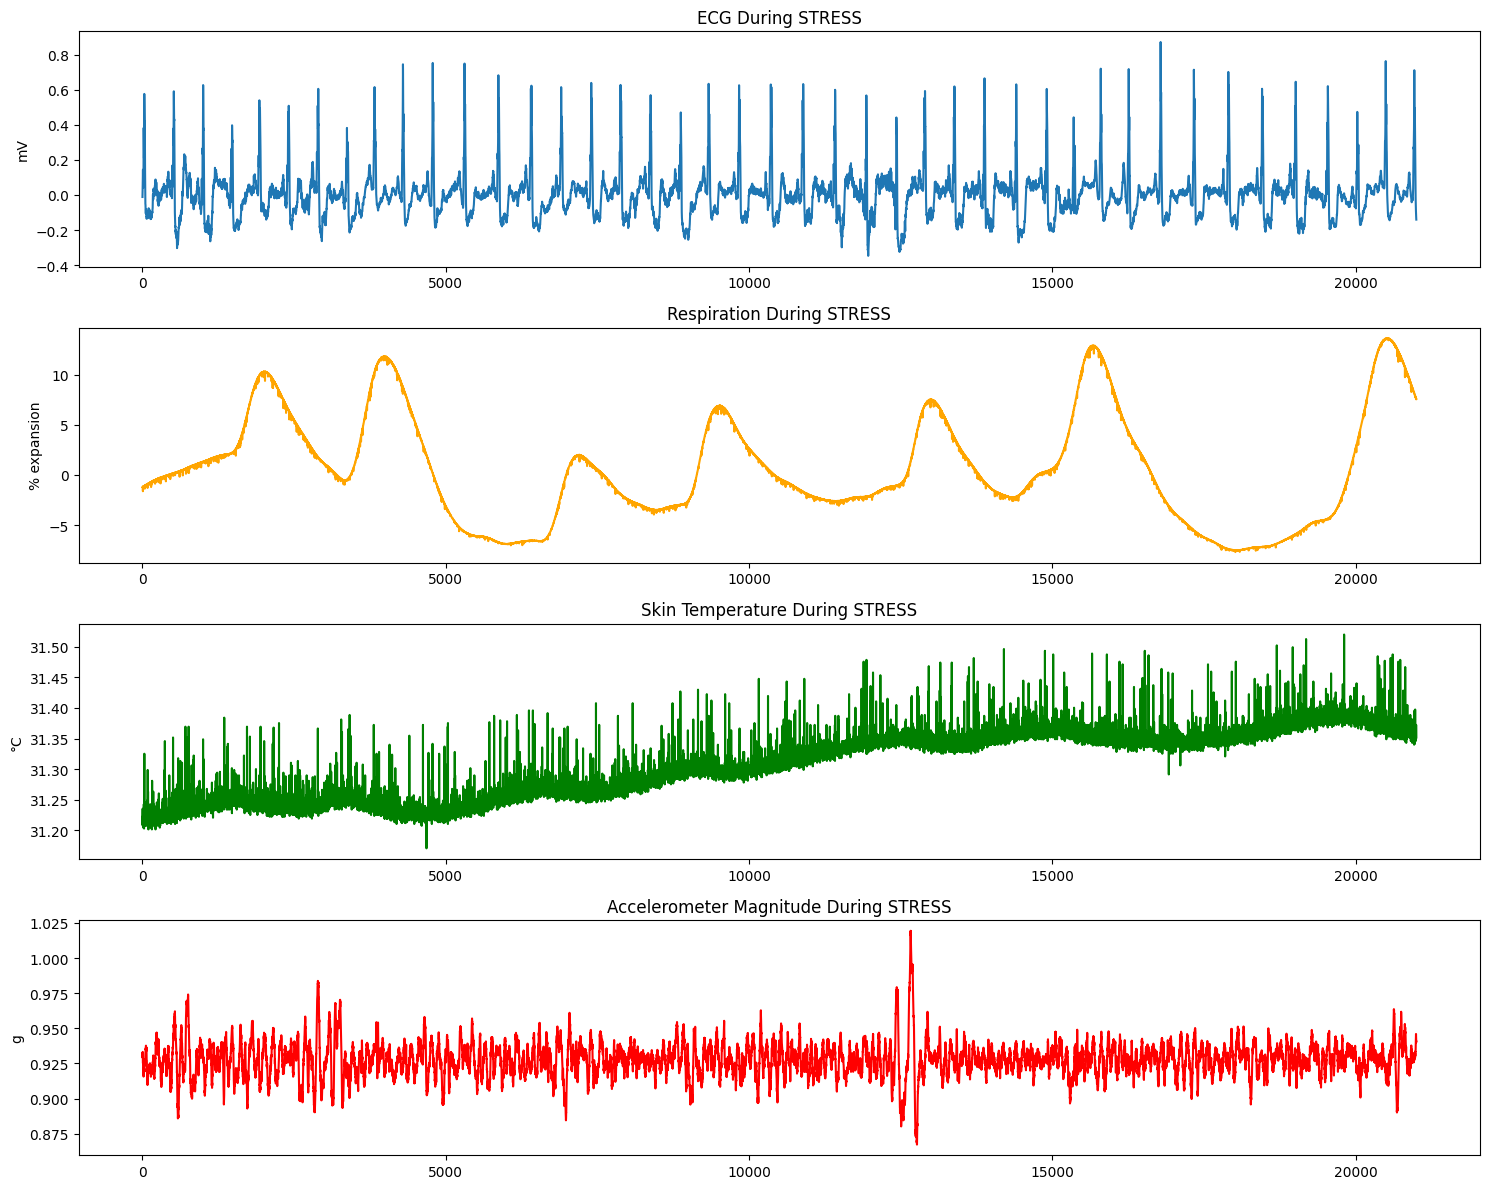

In [18]:
# Find where stress label starts
stress_start = np.where(labels == 2)[0][0]

fig, axes = plt.subplots(4, 1, figsize=(15, 12))

samples = 21000

axes[0].plot(ecg[stress_start:stress_start+samples])
axes[0].set_title('ECG During STRESS')
axes[0].set_ylabel('mV')

axes[1].plot(resp[stress_start:stress_start+samples], color='orange')
axes[1].set_title('Respiration During STRESS')
axes[1].set_ylabel('% expansion')

axes[2].plot(temp[stress_start:stress_start+samples], color='green')
axes[2].set_title('Skin Temperature During STRESS')
axes[2].set_ylabel('°C')

axes[3].plot(acc_mag[stress_start:stress_start+samples], color='red')
axes[3].set_title('Accelerometer Magnitude During STRESS')
axes[3].set_ylabel('g')

plt.tight_layout()
plt.show()

In [19]:
!pip install neurokit2 -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 37.8 MB/s eta 0:00:00


In [20]:
import neurokit2 as nk
import numpy as np
import pickle

# Load S2
with open(f'{wesad_path}/S2/S2.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

chest = data['signal']['chest']
labels = data['label'].flatten()

# Extract our 4 signals
ecg  = chest['ECG'].flatten()
resp = chest['Resp'].flatten()
temp = chest['Temp'].flatten()
acc  = chest['ACC']
acc_mag = np.sqrt(acc[:,0]**2 + acc[:,1]**2 + acc[:,2]**2)

# Separate baseline and stress indices
baseline_idx = np.where(labels == 1)[0]
stress_idx   = np.where(labels == 2)[0]

print(f"Baseline samples: {len(baseline_idx)}")
print(f"Stress samples:   {len(stress_idx)}")

# Extract baseline and stress segments
ecg_base  = ecg[baseline_idx]
resp_base = resp[baseline_idx]
temp_base = temp[baseline_idx]
acc_base  = acc_mag[baseline_idx]

ecg_stress  = ecg[stress_idx]
resp_stress = resp[stress_idx]
temp_stress = temp[stress_idx]
acc_stress  = acc_mag[stress_idx]

print("Signals separated successfully")

Baseline samples: 800800
Stress samples:   430500
Signals separated successfully


In [21]:
# ============================================================
# DATA QUALITY CHECK — Run this before any feature extraction
# ============================================================
print("Running data quality checks across all subjects...\n")

subjects = ['S2','S3','S4','S5','S6','S7','S8','S9','S10',
            'S11','S13','S14','S15','S16','S17']

SAMPLING_RATE = 700
FLAT_WINDOW   = 10 * SAMPLING_RATE  # 10 seconds to check for flat signal

quality_report = {}

for sid in subjects:
    issues = []
    pkl_path = f'{wesad_path}/{sid}/{sid}.pkl'

    with open(pkl_path, 'rb') as f:
        d = pickle.load(f, encoding='latin1')

    chest  = d['signal']['chest']
    labels = d['label'].flatten()
    ecg    = chest['ECG'].flatten()
    resp   = chest['Resp'].flatten()
    temp   = chest['Temp'].flatten()
    acc    = chest['ACC']
    acc_mag = np.sqrt(acc[:,0]**2 + acc[:,1]**2 + acc[:,2]**2)

    # --- Check 1: NaN values ---
    for name, sig in [('ECG',ecg),('Resp',resp),('Temp',temp),('ACC',acc_mag)]:
        n = np.sum(np.isnan(sig))
        if n > 0:
            issues.append(f'NaN in {name}: {n} samples')

    # --- Check 2: Infinite values ---
    for name, sig in [('ECG',ecg),('Resp',resp),('Temp',temp),('ACC',acc_mag)]:
        n = np.sum(np.isinf(sig))
        if n > 0:
            issues.append(f'Inf in {name}: {n} samples')

    # --- Check 3: Flat signal (sensor disconnect) ---
    # Check in 10-second chunks — if std is near zero, signal is flat/dead
    for name, sig in [('ECG',ecg),('Resp',resp),('Temp',temp),('ACC',acc_mag)]:
        flat_chunks = 0
        for start in range(0, len(sig) - FLAT_WINDOW, FLAT_WINDOW):
            chunk_std = np.std(sig[start:start+FLAT_WINDOW])
            if chunk_std < 1e-6:
                flat_chunks += 1
        if flat_chunks > 0:
            issues.append(f'Flat signal in {name}: {flat_chunks} chunks')

    # --- Check 4: Label availability ---
    has_baseline = np.sum(labels == 1) > 0
    has_stress   = np.sum(labels == 2) > 0
    if not has_baseline:
        issues.append('Missing baseline label (1)')
    if not has_stress:
        issues.append('Missing stress label (2)')

    # --- Check 5: Physiological range on raw signals ---
    # ECG should be roughly between -2 and 2 mV
    if np.max(np.abs(ecg)) > 5:
        issues.append(f'ECG spike > 5mV: max={np.max(np.abs(ecg)):.2f}')
    # Temperature should be between 25 and 42°C
    if np.min(temp) < 20 or np.max(temp) > 42:
        issues.append(f'Temp out of range: min={np.min(temp):.1f} max={np.max(temp):.1f}')

    quality_report[sid] = issues

    if issues:
        print(f"{sid} ⚠️  {', '.join(issues)}")
    else:
        print(f"{sid} ✅ No issues found")

print("\nQuality check complete.")

Running data quality checks across all subjects...

S2 ✅ No issues found
S3 ⚠️  Temp out of range: min=-273.1 max=34.5
S4 ✅ No issues found
S5 ✅ No issues found
S6 ✅ No issues found
S7 ✅ No issues found
S8 ✅ No issues found
S9 ✅ No issues found
S10 ✅ No issues found
S11 ✅ No issues found
S13 ✅ No issues found
S14 ✅ No issues found
S15 ✅ No issues found
S16 ✅ No issues found
S17 ✅ No issues found

Quality check complete.


In [22]:
# Investigate S3 temperature
with open(f'{wesad_path}/S3/S3.pkl', 'rb') as f:
    d_s3 = pickle.load(f, encoding='latin1')

temp_s3 = d_s3['signal']['chest']['Temp'].flatten()

print(f"S3 Temp min:    {np.min(temp_s3):.2f}°C")
print(f"S3 Temp max:    {np.max(temp_s3):.2f}°C")
print(f"S3 Temp mean:   {np.mean(temp_s3):.2f}°C")
print(f"\nHow many samples below 20°C: {np.sum(temp_s3 < 20)}")
print(f"How many samples above 20°C: {np.sum(temp_s3 > 20)}")
print(f"Total samples:               {len(temp_s3)}")

S3 Temp min:    -273.15°C
S3 Temp max:    34.52°C
S3 Temp mean:   32.55°C

How many samples below 20°C: 83
How many samples above 20°C: 4545017
Total samples:               4545100


In [23]:
# Verify S3 bad samples are NOT in baseline (label=1)
labels_s3 = d_s3['label'].flatten()
bad_sample_indices = np.where(temp_s3 < 20)[0]

print("S3 bad sample label distribution:")
for idx in bad_sample_indices[:10]:  # show first 10
    print(f"  Sample {idx}: label={labels_s3[idx]}, temp={temp_s3[idx]:.2f}°C")

bad_in_baseline = np.sum(labels_s3[bad_sample_indices] == 1)
bad_in_stress   = np.sum(labels_s3[bad_sample_indices] == 2)
bad_in_other    = np.sum(
    (labels_s3[bad_sample_indices] != 1) &
    (labels_s3[bad_sample_indices] != 2)
)

print(f"\nBad samples in baseline (label=1): {bad_in_baseline}")
print(f"Bad samples in stress   (label=2): {bad_in_stress}")
print(f"Bad samples in other    (label=0,3,4): {bad_in_other}")

S3 bad sample label distribution:
  Sample 1771710: label=2, temp=-273.15°C
  Sample 1771711: label=2, temp=-273.15°C
  Sample 1771712: label=2, temp=-273.15°C
  Sample 1771713: label=2, temp=-273.15°C
  Sample 1771714: label=2, temp=-273.15°C
  Sample 1771715: label=2, temp=-273.15°C
  Sample 1771716: label=2, temp=-273.15°C
  Sample 1771717: label=2, temp=-273.15°C
  Sample 1771718: label=2, temp=-273.15°C
  Sample 1771719: label=2, temp=-273.15°C

Bad samples in baseline (label=1): 0
Bad samples in stress   (label=2): 83
Bad samples in other    (label=0,3,4): 0


In [24]:
import json

# Add S3 investigation findings FIRST before saving
quality_report['S3'].append(
    'Temp -273.15C in 83 samples - confirmed all in label=2 (stress). '
    'Zero bad samples in baseline (label=1). '
    'S3 stress already excluded from evaluation. '
    'Handled by per-sample min check (temp < 10C) in extract_all_windows.'
)

# NOW serialize and save — S3 finding is included
quality_report_serializable = {
    sid: issues for sid, issues in quality_report.items()
}

with open(f'{wesad_reports}/WESAD_quality_report.json', 'w') as f:
    json.dump(quality_report_serializable, f, indent=2)

print("Quality report saved to Drive ✓")

Quality report saved to Drive ✓


In [25]:
# Extract HRV features from ECG using neurokit2
# We work on a smaller chunk first to test - 60 seconds of baseline
SAMPLING_RATE = 700
sixty_seconds = 60 * SAMPLING_RATE  # 42000 samples

ecg_chunk = ecg_base[:sixty_seconds]

# Clean ECG and find R-peaks
ecg_cleaned = nk.ecg_clean(ecg_chunk, sampling_rate=SAMPLING_RATE)
peaks, info = nk.ecg_peaks(ecg_cleaned, sampling_rate=SAMPLING_RATE)

# Extract HRV features
hrv_features = nk.hrv_time(peaks, sampling_rate=SAMPLING_RATE, show=False)

print("HRV features extracted:")
print(hrv_features[['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD']].to_string())

HRV features extracted:
   HRV_MeanNN   HRV_SDNN  HRV_RMSSD
0  742.803571  96.414256   65.99261


In [26]:
# Same calculation but on stress ECG
ecg_stress_chunk = ecg_stress[:sixty_seconds]

ecg_stress_cleaned = nk.ecg_clean(ecg_stress_chunk, sampling_rate=SAMPLING_RATE)
stress_peaks, _ = nk.ecg_peaks(ecg_stress_cleaned, sampling_rate=SAMPLING_RATE)

hrv_stress = nk.hrv_time(stress_peaks, sampling_rate=SAMPLING_RATE, show=False)

print("Baseline HRV:")
print(hrv_features[['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD']].to_string())

print("\nStress HRV:")
print(hrv_stress[['HRV_MeanNN', 'HRV_SDNN', 'HRV_RMSSD']].to_string())

Baseline HRV:
   HRV_MeanNN   HRV_SDNN  HRV_RMSSD
0  742.803571  96.414256   65.99261

Stress HRV:
   HRV_MeanNN   HRV_SDNN  HRV_RMSSD
0  730.793651  47.973207  35.120783


In [27]:
def extract_features_from_window(ecg_window, resp_window,
                                  temp_window, acc_window,
                                  sampling_rate=700):
    features = []

    # --- ECG: HRV features (5 features) ---
    try:
        ecg_cleaned = nk.ecg_clean(ecg_window, sampling_rate=sampling_rate)
        peaks, _    = nk.ecg_peaks(ecg_cleaned, sampling_rate=sampling_rate)
        peak_idx    = np.where(peaks['ECG_R_Peaks'] == 1)[0]

        if len(peak_idx) < 8:
            return None

        rr_ms = np.diff(peak_idx) / sampling_rate * 1000  # convert to ms

        # Physiological filter: 30–220 bpm
        rr_ms = rr_ms[(rr_ms >= 273) & (rr_ms <= 2000)]
        if len(rr_ms) < 7:
            return None

        mean_rr = float(np.mean(rr_ms))
        mean_hr = 60000.0 / mean_rr
        sdnn    = float(np.std(rr_ms, ddof=1))
        rmssd   = float(np.sqrt(np.mean(np.diff(rr_ms) ** 2)))
        pnn50   = float(np.sum(np.abs(np.diff(rr_ms)) > 50) / len(rr_ms) * 100)

        if any(np.isnan([mean_hr, mean_rr, sdnn, rmssd, pnn50])):
            return None
        if mean_rr < 273 or mean_rr > 2000:
            return None

        features.extend([mean_hr, mean_rr, sdnn, rmssd, pnn50])

    except:
        return None

    # --- Respiration: mean_BR and std_BR (2 features) ---
    try:
        resp_cleaned = nk.rsp_clean(resp_window, sampling_rate=sampling_rate)
        rsp_rate_arr = nk.rsp_rate(resp_cleaned, sampling_rate=sampling_rate)
        mean_br = float(np.mean(rsp_rate_arr))
        std_br  = float(np.std(rsp_rate_arr))
        if any(np.isnan([mean_br, std_br])):
            return None
        if mean_br < 3 or mean_br > 60:
            return None
        features.extend([mean_br, std_br])
    except:
        return None

    # --- Temperature: mean_temp and std_temp (2 features) ---
    mean_temp = float(np.mean(temp_window))
    std_temp  = float(np.std(temp_window))
    if np.isnan(mean_temp) or np.isnan(std_temp):
        return None
    features.extend([mean_temp, std_temp])

    # --- Accelerometer: mean_acc_mag and std_acc_mag (2 features) ---
    mean_acc_mag = float(np.mean(acc_window))
    std_acc_mag  = float(np.std(acc_window))
    if np.isnan(mean_acc_mag) or np.isnan(std_acc_mag):
        return None
    features.extend([mean_acc_mag, std_acc_mag])

    return features  # length = 11


# Test on one window
SAMPLING_RATE = 700
WINDOW_SIZE   = 60 * SAMPLING_RATE

test_features = extract_features_from_window(
    ecg_base[:WINDOW_SIZE],
    resp_base[:WINDOW_SIZE],
    temp_base[:WINDOW_SIZE],
    acc_base[:WINDOW_SIZE]
)

if test_features is None:
    print("Window rejected — check signal quality")
else:
    print(f"Feature vector length: {len(test_features)}")
    names = ['mean_HR','mean_RR','SDNN','RMSSD','pNN50',
             'mean_BR','std_BR','mean_temp','std_temp','mean_acc_mag','std_acc_mag']
    print(f"Features: {', '.join(names)}")
    print(f"Values: {[round(f, 4) for f in test_features]}")

Feature vector length: 11
Features: mean_HR, mean_RR, SDNN, RMSSD, pNN50, mean_BR, std_BR, mean_temp, std_temp, mean_acc_mag, std_acc_mag
Values: [80.7751, 742.8036, 96.4143, 65.9926, 23.75, 19.3689, 5.5088, 29.1566, 0.0753, 0.9407, 0.0241]


In [28]:
def extract_all_windows(ecg, resp, temp, acc,
                         sampling_rate=700, window_sec=60, overlap=0.5):
    window_size = window_sec * sampling_rate
    step_size   = int(window_size * (1 - overlap))

    feature_vectors  = []
    rejected_artifact = 0
    rejected_flat     = 0
    rejected_feature  = 0
    start = 0

    while start + window_size <= len(ecg):
        end = start + window_size

        ecg_w  = ecg[start:end]
        resp_w = resp[start:end]
        temp_w = temp[start:end]
        acc_w  = acc[start:end]

        # Reject 1: NaN or Inf
        if (np.any(np.isnan(ecg_w))  or np.any(np.isinf(ecg_w))  or
            np.any(np.isnan(resp_w)) or np.any(np.isinf(resp_w)) or
            np.any(np.isnan(temp_w)) or np.any(np.isinf(temp_w)) or
            np.any(np.isnan(acc_w))  or np.any(np.isinf(acc_w))):
            start += step_size
            rejected_artifact += 1
            continue

        # Reject 2: Flat signal
        if (np.std(ecg_w)  < 1e-6 or
            np.std(resp_w) < 1e-6 or
            np.std(temp_w) < 1e-6):
            start += step_size
            rejected_flat += 1
            continue

        # Reject 3: Temperature out of range
        if np.mean(temp_w) < 25 or np.mean(temp_w) > 38:
            start += step_size
            rejected_artifact += 1
            continue

        # Reject 3b: Physically impossible temperature values
        if np.min(temp_w) < 10:
            start += step_size
            rejected_artifact += 1
            continue

        # Reject 4: Motion artifact
        if np.max(acc_w) > 3:
            start += step_size
            rejected_artifact += 1
            continue

        # Extract features
        feats = extract_features_from_window(
            ecg_w, resp_w, temp_w, acc_w, sampling_rate
        )

        # Reject 5: Feature extraction failed or NaN
        if feats is None:
            start += step_size
            rejected_feature += 1
            continue

        if any(np.isnan(feats)):
            start += step_size
            rejected_feature += 1
            continue

        feature_vectors.append(feats)
        start += step_size

    total_rejected = rejected_artifact + rejected_flat + rejected_feature
    if total_rejected > 0:
        print(f"    Rejected: {rejected_artifact} artifact, "
              f"{rejected_flat} flat, "
              f"{rejected_feature} failed extraction")

    if not feature_vectors:
        return np.array([]).reshape(0, 11)

    return np.array(feature_vectors)

print("extract_all_windows defined ✓")

extract_all_windows defined ✓


In [29]:
# Save feature names so we always know what each column means
feature_names = [
    'mean_HR', 'mean_RR', 'SDNN', 'RMSSD', 'pNN50',
    'mean_BR', 'std_BR',
    'mean_temp', 'std_temp',
    'mean_acc_mag', 'std_acc_mag'
]

import json
with open(f'{base_output}/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

print("Feature names saved:")
for i, name in enumerate(feature_names):
    print(f"  Column {i}: {name}")

Feature names saved:
  Column 0: mean_HR
  Column 1: mean_RR
  Column 2: SDNN
  Column 3: RMSSD
  Column 4: pNN50
  Column 5: mean_BR
  Column 6: std_BR
  Column 7: mean_temp
  Column 8: std_temp
  Column 9: mean_acc_mag
  Column 10: std_acc_mag


In [30]:
import os
os.makedirs(wesad_per_subject, exist_ok=True)

subjects = ['S2','S3','S4','S5','S6','S7','S8','S9','S10',
            'S11','S13','S14','S15','S16','S17']

# S3 and S6: baseline kept for training
# but stress windows excluded from evaluation
# because neither subject was actually stressed during TSST
EXCLUDE_STRESS_EVAL = ['S3', 'S6']

# Subjects with known confounds — kept but flagged
FLAGGED_SUBJECTS = {
    'S2':  'Temp sensor not fully attached',
    'S17': 'Temp sensor not fully attached',
    'S3':  'Sunny workplace during baseline. Cheerful during stress — stress excluded from eval',
    'S6':  'Not stressed during TSST — stress excluded from eval',
    'S8':  'Pre-study stress. Felt cold during stress condition',
    'S9':  'Felt ill on study day',
    'S15': 'Did not believe TSST cover story',
    'S16': 'Felt cold during stress condition',
}

all_baseline = {}
all_stress   = {}
failed       = []

for sid in subjects:
    print(f"Processing {sid}...", end=" ")
    try:
        pkl_path = f'{wesad_path}/{sid}/{sid}.pkl'
        with open(pkl_path, 'rb') as f:
            d = pickle.load(f, encoding='latin1')

        chest   = d['signal']['chest']
        labels  = d['label'].flatten()
        ecg     = chest['ECG'].flatten()
        resp    = chest['Resp'].flatten()
        temp    = chest['Temp'].flatten()
        acc     = chest['ACC']
        acc_mag = np.sqrt(acc[:,0]**2 + acc[:,1]**2 + acc[:,2]**2)

        # Verify both labels exist
        if np.sum(labels == 1) == 0:
            print(f"✗ Missing baseline label")
            failed.append(sid)
            continue
        if np.sum(labels == 2) == 0:
            print(f"✗ Missing stress label")
            failed.append(sid)
            continue

        b_idx = np.where(labels == 1)[0]
        s_idx = np.where(labels == 2)[0]

        ecg_b  = ecg[b_idx];     ecg_s  = ecg[s_idx]
        resp_b = resp[b_idx];    resp_s = resp[s_idx]
        temp_b = temp[b_idx];    temp_s = temp[s_idx]
        acc_b  = acc_mag[b_idx]; acc_s  = acc_mag[s_idx]

        # Extract baseline windows — all subjects
        base_feats = extract_all_windows(ecg_b, resp_b, temp_b, acc_b)

        # Extract stress windows — all subjects
        # But mark excluded ones so they don't go into evaluation
        stress_feats = extract_all_windows(ecg_s, resp_s, temp_s, acc_s)

        # Verify enough baseline windows remain
        if len(base_feats) < 5:
            print(f"✗ Too few baseline windows ({len(base_feats)}) after rejection")
            failed.append(sid)
            continue

        # For excluded subjects, stress windows saved separately
        # so they are never mixed into evaluation
        if sid in EXCLUDE_STRESS_EVAL:
            if len(stress_feats) > 0:
                np.save(f'{wesad_per_subject}/{sid}_stress_EXCLUDED_from_eval.npy',
                        stress_feats)
            stress_feats = np.array([]).reshape(0, 11)
            print(f"  ⚠️  Stress windows excluded from evaluation ({sid})")

        # Normalize using baseline stats
        b_mean = np.mean(base_feats, axis=0)
        b_std  = np.std(base_feats, axis=0)
        b_std[b_std == 0] = 1e-8

        base_norm   = (base_feats   - b_mean) / b_std

        # Final NaN check on baseline
        if np.any(np.isnan(base_norm)):
            print(f"✗ NaN after normalization")
            failed.append(sid)
            continue

        # Normalize stress only if not excluded
        if len(stress_feats) > 0:
            stress_norm = (stress_feats - b_mean) / b_std
            if np.any(np.isnan(stress_norm)):
                print(f"✗ NaN in stress after normalization")
                failed.append(sid)
                continue
        else:
            stress_norm = np.array([]).reshape(0, 11)

        # Save
        np.save(f'{wesad_per_subject}/{sid}_baseline_normalized.npy', base_norm)
        np.save(f'{wesad_per_subject}/{sid}_stress_normalized.npy',   stress_norm)
        np.save(f'{wesad_per_subject}/{sid}_norm_params_mean.npy',    b_mean)
        np.save(f'{wesad_per_subject}/{sid}_norm_params_std.npy',     b_std)

        all_baseline[sid] = base_norm
        all_stress[sid]   = stress_norm

        flag = f" [{FLAGGED_SUBJECTS[sid]}]" if sid in FLAGGED_SUBJECTS else ""
        print(f"✓ baseline{base_norm.shape} stress{stress_norm.shape}{flag}")

    except Exception as e:
        print(f"✗ FAILED: {e}")
        failed.append(sid)

print(f"\nDone. Failed: {failed if failed else 'None'}")
print(f"Subjects excluded from stress eval: {EXCLUDE_STRESS_EVAL}")

Processing S2... ✓ baseline(37, 11) stress(19, 11) [Temp sensor not fully attached]
Processing S3...     Rejected: 2 artifact, 0 flat, 0 failed extraction
  ⚠️  Stress windows excluded from evaluation (S3)
✓ baseline(37, 11) stress(0, 11) [Sunny workplace during baseline. Cheerful during stress — stress excluded from eval]
Processing S4... ✓ baseline(37, 11) stress(20, 11)
Processing S5... ✓ baseline(38, 11) stress(20, 11)
Processing S6...   ⚠️  Stress windows excluded from evaluation (S6)
✓ baseline(38, 11) stress(0, 11) [Not stressed during TSST — stress excluded from eval]
Processing S7... ✓ baseline(38, 11) stress(20, 11)
Processing S8... ✓ baseline(37, 11) stress(21, 11) [Pre-study stress. Felt cold during stress condition]
Processing S9... ✓ baseline(38, 11) stress(20, 11) [Felt ill on study day]
Processing S10... ✓ baseline(38, 11) stress(23, 11)
Processing S11... ✓ baseline(38, 11) stress(21, 11)
Processing S13... ✓ baseline(38, 11) stress(21, 11)
Processing S14... ✓ baseline(3

In [31]:
total_baseline_windows = sum(all_baseline[sid].shape[0] for sid in subjects)
total_stress_windows   = sum(all_stress[sid].shape[0] for sid in subjects)

print(f"Total subjects:          {len(subjects)}")
print(f"Total baseline windows:  {total_baseline_windows}")
print(f"Total stress windows:    {total_stress_windows}")
print(f"Features per window:     11")
print(f"\nThis means the model will train on {total_baseline_windows} windows")
print(f"And be tested on {total_stress_windows} stress windows")

Total subjects:          15
Total baseline windows:  566
Total stress windows:    271
Features per window:     11

This means the model will train on 566 windows
And be tested on 271 stress windows


In [32]:
# Stack all subjects into combined arrays
# Keep track of which subject each window belongs to
all_baseline_combined = []
all_stress_combined   = []
subject_labels_base   = []
subject_labels_stress = []

for sid in subjects:
    all_baseline_combined.append(all_baseline[sid])
    all_stress_combined.append(all_stress[sid])

    # Record subject ID for each window
    subject_labels_base.extend([sid] * all_baseline[sid].shape[0])
    subject_labels_stress.extend([sid] * all_stress[sid].shape[0])

all_baseline_combined = np.vstack(all_baseline_combined)
all_stress_combined   = np.vstack(all_stress_combined)

# Save combined arrays
np.save(f'{wesad_combined}/WESAD_all_baseline.npy', all_baseline_combined)
np.save(f'{wesad_combined}/WESAD_all_stress.npy',   all_stress_combined)

# Save subject labels
np.save(f'{wesad_combined}/WESAD_subject_labels_base.npy',
        np.array(subject_labels_base))
np.save(f'{wesad_combined}/WESAD_subject_labels_stress.npy',
        np.array(subject_labels_stress))

print(f"Combined baseline shape: {all_baseline_combined.shape}")
print(f"Combined stress shape:   {all_stress_combined.shape}")
print(f"\nAll files saved to Drive ✓")

Combined baseline shape: (566, 11)
Combined stress shape:   (271, 11)

All files saved to Drive ✓


In [33]:
# ============================================================
# FINAL INTEGRITY CHECK — Verify everything saved correctly
# ============================================================
print("Running final integrity check on saved files...\n")

baseline_saved = np.load(f'{wesad_combined}/WESAD_all_baseline.npy')
stress_saved   = np.load(f'{wesad_combined}/WESAD_all_stress.npy')
base_labels    = np.load(f'{wesad_combined}/WESAD_subject_labels_base.npy')
stress_labels  = np.load(f'{wesad_combined}/WESAD_subject_labels_stress.npy')

print(f"Baseline array shape:     {baseline_saved.shape}")
print(f"Stress array shape:       {stress_saved.shape}")
print(f"Baseline subject labels:  {len(base_labels)}")
print(f"Stress subject labels:    {len(stress_labels)}")

# Check NaN
nan_base   = np.sum(np.isnan(baseline_saved))
nan_stress = np.sum(np.isnan(stress_saved))
print(f"\nNaN in baseline: {nan_base}")
print(f"NaN in stress:   {nan_stress}")

# Check shapes match labels
assert baseline_saved.shape[0] == len(base_labels), "Baseline shape mismatch!"
assert stress_saved.shape[0]   == len(stress_labels), "Stress shape mismatch!"
assert nan_base   == 0, "NaN found in baseline!"
assert nan_stress == 0, "NaN found in stress!"

print("\n✅ All checks passed. WESAD preprocessing complete and verified.")
print(f"\nFinal summary:")
print(f"  Subjects:         15")
print(f"  Baseline windows: {baseline_saved.shape[0]}")
print(f"  Stress windows:   {stress_saved.shape[0]}")
print(f"  Features:         {baseline_saved.shape[1]}")
print(f"  Stress excluded:  S3, S6")

Running final integrity check on saved files...

Baseline array shape:     (566, 11)
Stress array shape:       (271, 11)
Baseline subject labels:  566
Stress subject labels:    271

NaN in baseline: 0
NaN in stress:   0

✅ All checks passed. WESAD preprocessing complete and verified.

Final summary:
  Subjects:         15
  Baseline windows: 566
  Stress windows:   271
  Features:         11
  Stress excluded:  S3, S6


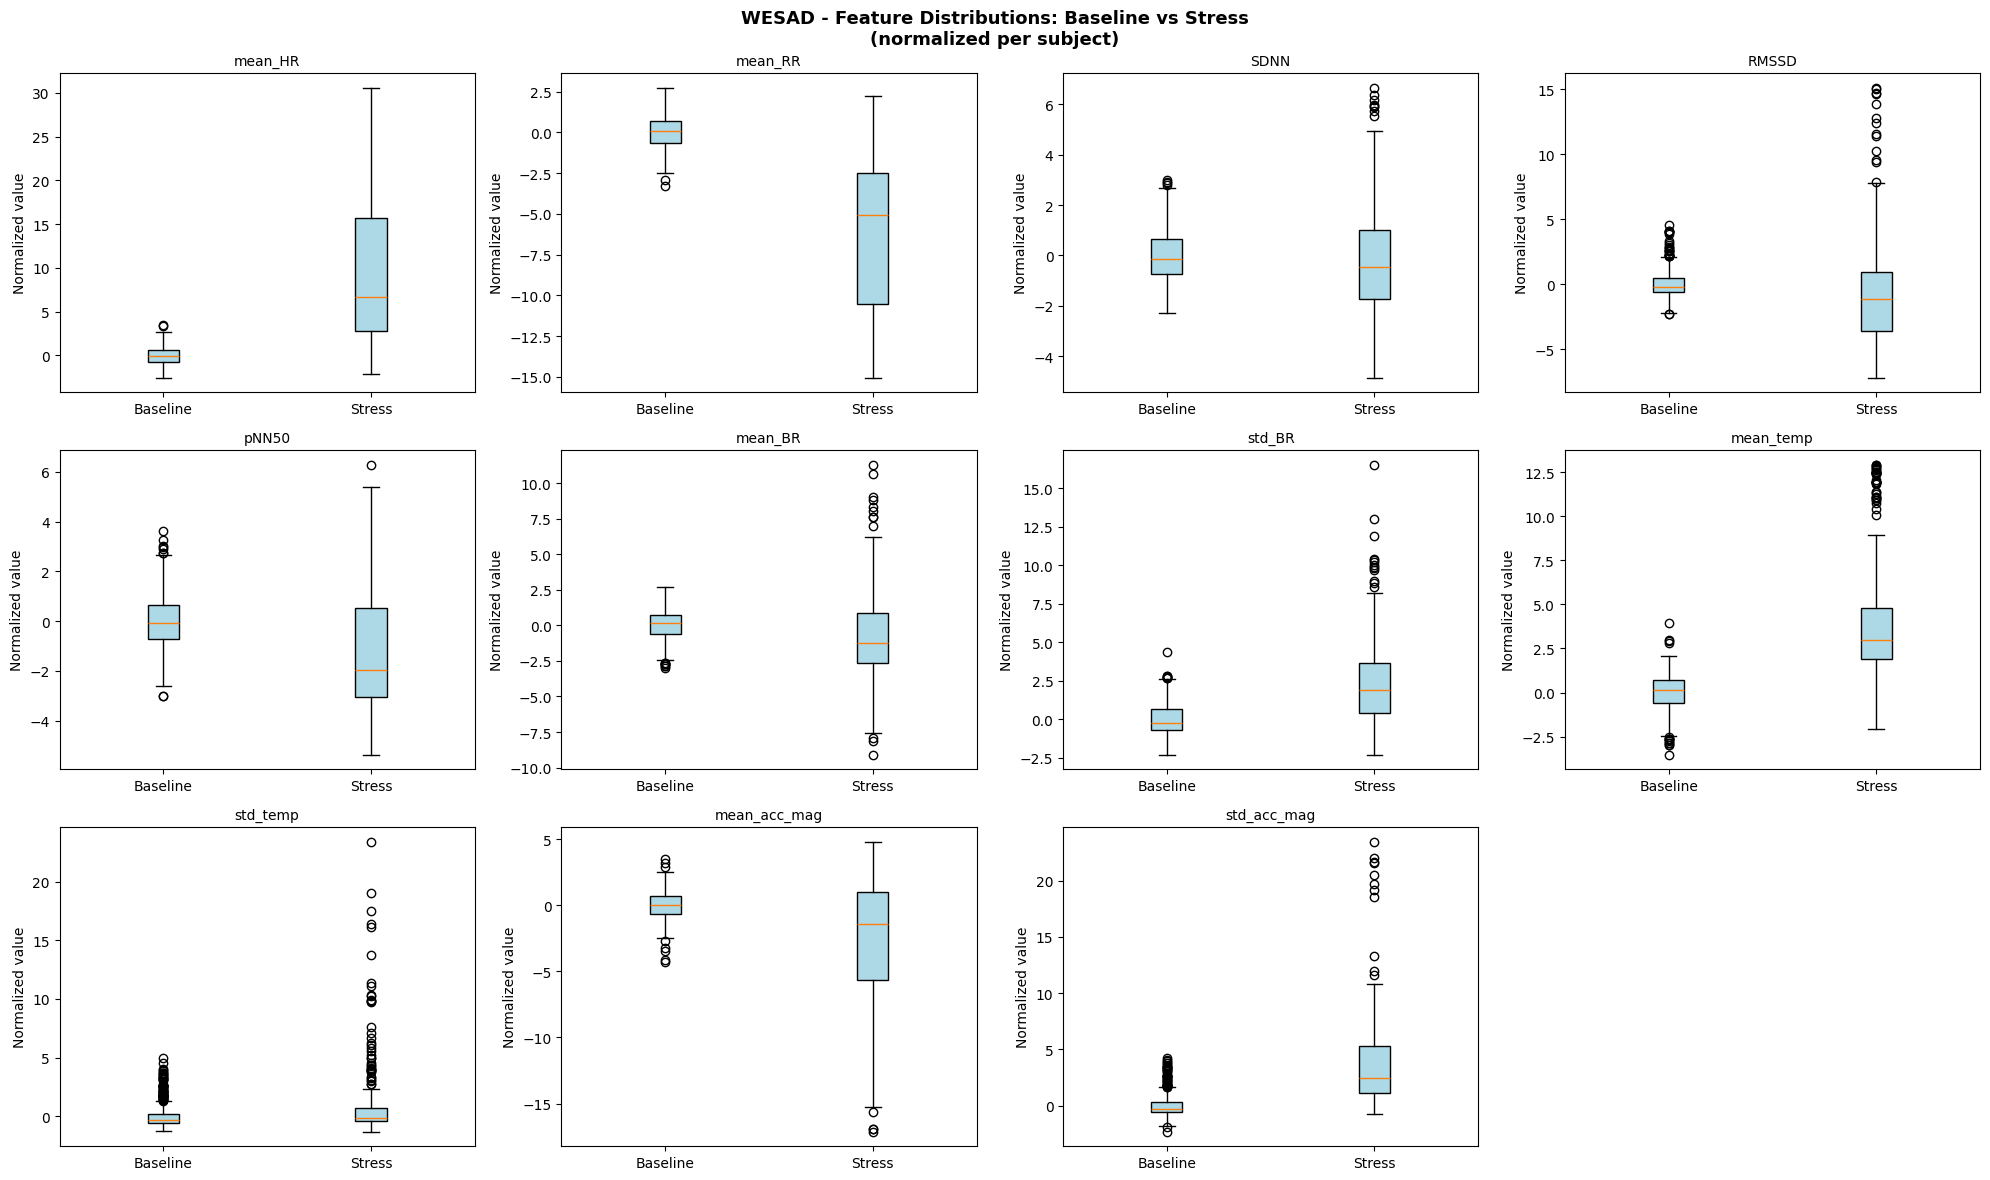

Saved ✓


In [35]:
import matplotlib.pyplot as plt
import numpy as np
import os

feature_names = [
    'mean_HR', 'mean_RR', 'SDNN', 'RMSSD', 'pNN50',
    'mean_BR', 'std_BR',
    'mean_temp', 'std_temp',
    'mean_acc_mag', 'std_acc_mag'
]

plots_path = wesad_plots
os.makedirs(plots_path, exist_ok=True)

baseline_saved = np.load(f'{wesad_combined}/WESAD_all_baseline.npy')
stress_saved   = np.load(f'{wesad_combined}/WESAD_all_stress.npy')

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.flatten()

for i, name in enumerate(feature_names):
    axes[i].boxplot(
        [baseline_saved[:, i], stress_saved[:, i]],
        tick_labels=['Baseline', 'Stress'],
        patch_artist=True,
        boxprops=dict(facecolor='lightblue'),
    )
    axes[i].set_title(name, fontsize=10)
    axes[i].set_ylabel('Normalized value')

# Hide the extra empty subplot
axes[-1].set_visible(False)

plt.suptitle('WESAD - Feature Distributions: Baseline vs Stress\n(normalized per subject)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_path}/WESAD_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

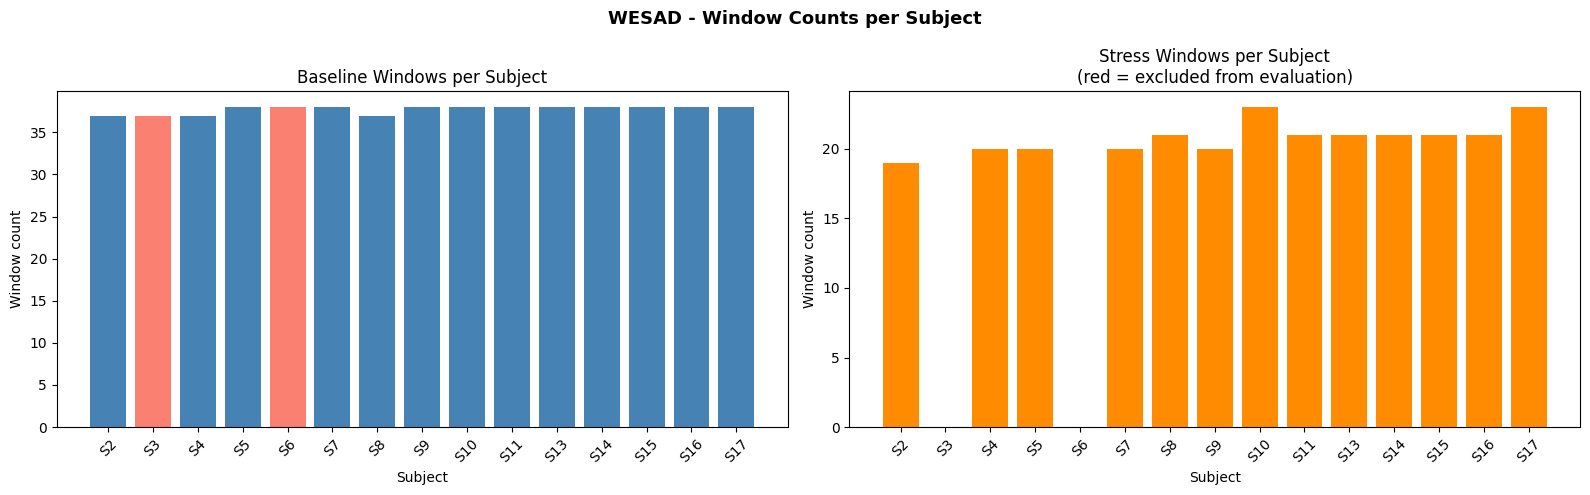

Saved ✓


In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sids = list(all_baseline.keys())
base_counts   = [all_baseline[s].shape[0] for s in sids]
stress_counts = [all_stress[s].shape[0]   for s in sids]

colors_base   = ['salmon' if s in ['S3','S6'] else 'steelblue' for s in sids]
colors_stress = ['salmon' if s in ['S3','S6'] else 'darkorange' for s in sids]

axes[0].bar(sids, base_counts, color=colors_base)
axes[0].set_title('Baseline Windows per Subject')
axes[0].set_xlabel('Subject')
axes[0].set_ylabel('Window count')
axes[0].tick_params(axis='x', rotation=45)

axes[1].bar(sids, stress_counts, color=colors_stress)
axes[1].set_title('Stress Windows per Subject\n(red = excluded from evaluation)')
axes[1].set_xlabel('Subject')
axes[1].set_ylabel('Window count')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('WESAD - Window Counts per Subject',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_path}/WESAD_window_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

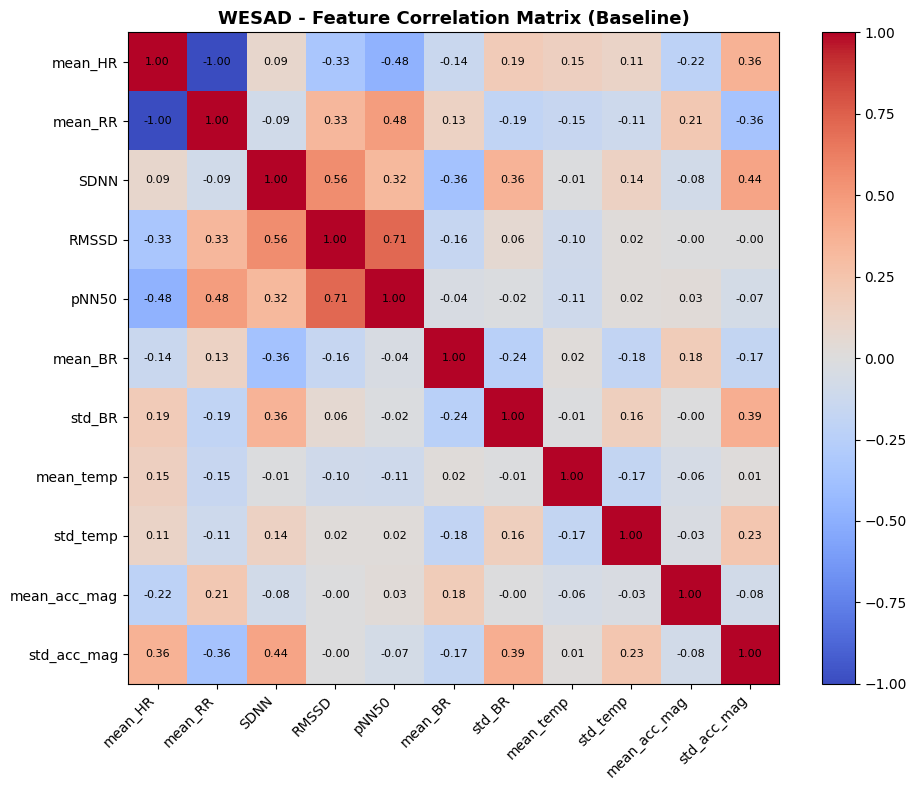

Saved ✓


In [37]:
import matplotlib.pyplot as plt

corr_matrix = np.corrcoef(baseline_saved.T)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)

ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=45, ha='right')
ax.set_yticklabels(feature_names)

# Add correlation values inside boxes
for i in range(len(feature_names)):
    for j in range(len(feature_names)):
        ax.text(j, i, f'{corr_matrix[i,j]:.2f}',
                ha='center', va='center', fontsize=8)

ax.set_title('WESAD - Feature Correlation Matrix (Baseline)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{plots_path}/WESAD_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

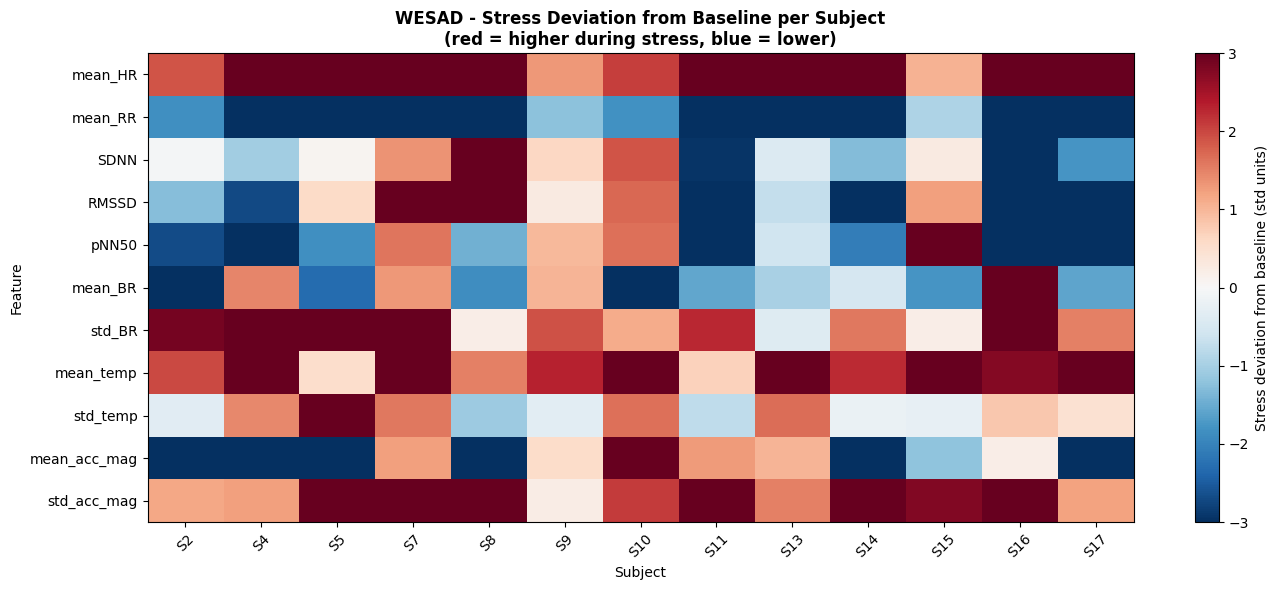

Saved ✓


In [38]:
fig, ax = plt.subplots(figsize=(14, 6))

sids_with_stress = [s for s in subjects if all_stress[s].shape[0] > 0]

stress_means   = [np.mean(all_stress[s],   axis=0) for s in sids_with_stress]
baseline_means = [np.mean(all_baseline[s], axis=0) for s in sids_with_stress]

stress_means   = np.array(stress_means)
baseline_means = np.array(baseline_means)

# Plot deviation (stress mean - baseline mean) per subject per feature
deviation = stress_means - baseline_means

im = ax.imshow(deviation.T, cmap='RdBu_r', aspect='auto', vmin=-3, vmax=3)
plt.colorbar(im, label='Stress deviation from baseline (std units)')

ax.set_xticks(range(len(sids_with_stress)))
ax.set_xticklabels(sids_with_stress, rotation=45)
ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels(feature_names)
ax.set_xlabel('Subject')
ax.set_ylabel('Feature')
ax.set_title('WESAD - Stress Deviation from Baseline per Subject\n(red = higher during stress, blue = lower)',
             fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(f'{plots_path}/WESAD_stress_deviation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved ✓")

In [41]:
import json
from datetime import datetime

report = {
    "dataset": "WESAD",
    "generated": datetime.now().strftime("%Y-%m-%d %H:%M"),
    "reference": "Schmidt et al., ICMI 2018",

    "overview": {
        "total_subjects": 15,
        "missing_subjects": ["S1", "S12"],
        "missing_reason": "Sensor malfunction during data collection",
        "sampling_rate_hz": 700,
        "device": "RespiBAN chest strap"
    },

    "signals_used": {
        "ECG":  "Cardiac electrical activity — used to extract HRV features",
        "Resp": "Thoracic respiration — used to extract breathing features",
        "Temp": "Chest skin temperature — used as thermal stress indicator",
        "ACC":  "3-axis accelerometer magnitude — used as motion indicator"
    },

    "signals_excluded": {
        "EMG": "Not available on custom chest strap hardware",
        "EDA": "Not available on custom chest strap hardware",
        "Wrist device": "Same session as chest device — no additional time coverage. Lower quality signals."
    },

    "labels_used": {
        "1 (Baseline)": "Used for SSL training — represents individual normal state",
        "2 (Stress)":   "Used for anomaly evaluation only — never seen during training",
        "0,3,4,5,6,7":  "Excluded — transition, amusement, meditation, undefined"
    },

    "preprocessing_steps": [
        "1. Load synchronized pkl file per subject",
        "2. Extract chest signals only: ECG, Resp, Temp, ACC magnitude",
        "3. Separate baseline (label=1) and stress (label=2) segments",
        "4. Data quality check: NaN, Inf, flat signal, physiological range, label availability",
        "5. Slide 60-second windows with 50% overlap",
        "6. Window-level artifact rejection: NaN/Inf, flat signal, Temp mean 25-38C, per-sample Temp min > 10C (absolute zero sensor error protection), ACC < 3g",
        "7. Feature extraction per window (11 features): mean_HR, mean_RR, SDNN, RMSSD, pNN50, mean_BR, std_BR, mean_temp, std_temp, mean_acc_mag, std_acc_mag",
        "8. Feature-level rejection: None return on failed extraction, NaN check, resp_rate physiological range 3-60 breaths/min, MeanNN physiological range 300-2000ms",
        "9. Z-score normalization using baseline statistics only",
        "10. Final NaN check after normalization",
        "11. Save per-subject and combined arrays"
    ],

    "windowing": {
        "window_duration_sec": 60,
        "overlap_percent": 50,
        "rationale": "60s is clinical minimum for reliable short-term HRV. 50% overlap doubles samples without redundancy."
    },

    "features": {
        "mean_HR":      "Mean heart rate (bpm) — 60000/mean_RR",
        "mean_RR":      "Mean RR interval (ms) — inversely related to heart rate",
        "SDNN":         "Std of RR intervals (ms) — overall HRV, drops under stress",
        "RMSSD":        "Root mean square successive differences (ms) — parasympathetic activity",
        "pNN50":        "Proportion of successive RR differences > 50ms (%) — vagal tone",
        "mean_BR":      "Mean breathing rate (breaths/min) from raw Resp signal",
        "std_BR":       "Std of instantaneous breathing rate — breathing irregularity",
        "mean_temp":    "Mean chest skin temperature (°C)",
        "std_temp":     "Std of chest temperature (°C) — thermal stability",
        "mean_acc_mag": "Mean accelerometer magnitude (g) — movement level",
        "std_acc_mag":  "Std of accelerometer magnitude (g) — movement variability"
    },

    "normalization": {
        "method": "Z-score per subject",
        "formula": "(value - baseline_mean) / baseline_std",
        "rationale": "Normalizes using individual baseline only. Stress deviations appear as units away from personal normal. Enables cross-subject and cross-dataset training."
    },

    "subjects_excluded_stress_eval": {
        "S3": "Cheerful during stress condition — no physiological stress response",
        "S6": "Did not feel stressed during TSST — no physiological stress response"
    },

    "flagged_subjects": {
        "S2":  "Temp sensor not fully attached throughout session",
        "S17": "Temp sensor not fully attached throughout session",
        "S8":  "Pre-study stress reported. Felt cold during stress condition",
        "S9":  "Felt ill on study day",
        "S15": "Did not believe TSST cover story",
        "S16": "Felt cold during stress condition"
    },

    "final_counts": {
        "baseline_windows": int(np.load(f'{wesad_combined}/WESAD_all_baseline.npy').shape[0]),
        "stress_windows":   int(np.load(f'{wesad_combined}/WESAD_all_stress.npy').shape[0]),
        "features_per_window": 11
    },

    "saved_files": {
        "WESAD_all_baseline.npy":            "All subjects combined baseline windows (566, 11)",
        "WESAD_all_stress.npy":              "All subjects combined stress windows (271, 11)",
        "WESAD_subject_labels_base.npy":     "Subject ID per baseline window",
        "WESAD_subject_labels_stress.npy":   "Subject ID per stress window",
        "SX_baseline_normalized.npy":        "Per-subject baseline (one file per subject)",
        "SX_stress_normalized.npy":          "Per-subject stress (one file per subject)",
        "SX_norm_params_mean.npy":           "Per-subject baseline mean for normalization",
        "SX_norm_params_std.npy":            "Per-subject baseline std for normalization",
        "feature_names.json":                "Column name mapping for all feature arrays",
        "WESAD_quality_report.json":         "Per-subject data quality issues found",
        "plots/WESAD_feature_distributions.png": "Boxplot baseline vs stress per feature",
        "plots/WESAD_window_counts.png":         "Bar chart of windows per subject",
        "plots/WESAD_feature_correlation.png":   "Feature correlation heatmap",
        "plots/WESAD_stress_deviation.png":      "Stress deviation heatmap per subject"
    }
}

with open(f'{wesad_reports}/WESAD_preprocessing_report.json', 'w') as f:
    json.dump(report, f, indent=2)

print("WESAD preprocessing report saved to Drive ✓")
print(f"\nLocation: {wesad_reports}/WESAD_preprocessing_report.json")

WESAD preprocessing report saved to Drive ✓

Location: /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/WESAD/reports/WESAD_preprocessing_report.json


In [40]:
!pip install reportlab -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 65.6 MB/s eta 0:00:00


In [42]:
# ============================================================
# GENERATE PDF PREPROCESSING REPORT
# ============================================================
import subprocess
subprocess.run(['pip', 'install', 'reportlab', '-q'])

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import (SimpleDocTemplate, Paragraph, Spacer,
                                 Table, TableStyle, HRFlowable)
from reportlab.lib.enums import TA_LEFT, TA_CENTER
import json
from datetime import datetime

# Load the saved report
with open(f'{wesad_reports}/WESAD_preprocessing_report.json', 'r') as f:
    report = json.load(f)

# Load quality report
with open(f'{wesad_reports}/WESAD_quality_report.json', 'r') as f:
    qreport = json.load(f)

pdf_path = f'{wesad_reports}/WESAD_preprocessing_report.pdf'
doc = SimpleDocTemplate(pdf_path, pagesize=A4,
                        rightMargin=2*cm, leftMargin=2*cm,
                        topMargin=2*cm, bottomMargin=2*cm)

styles = getSampleStyleSheet()

# Custom styles
title_style = ParagraphStyle('CustomTitle',
    parent=styles['Title'], fontSize=18, spaceAfter=6,
    textColor=colors.HexColor('#1a1a2e'))

h1_style = ParagraphStyle('H1',
    parent=styles['Heading1'], fontSize=13, spaceAfter=4,
    textColor=colors.HexColor('#16213e'), spaceBefore=12)

h2_style = ParagraphStyle('H2',
    parent=styles['Heading2'], fontSize=11, spaceAfter=3,
    textColor=colors.HexColor('#0f3460'), spaceBefore=8)

normal_style = ParagraphStyle('CustomNormal',
    parent=styles['Normal'], fontSize=9, spaceAfter=3,
    leading=14)

code_style = ParagraphStyle('Code',
    parent=styles['Normal'], fontSize=8,
    fontName='Courier', backColor=colors.HexColor('#f5f5f5'),
    spaceAfter=2, leading=12, leftIndent=10)

story = []

# ── Title ──
story.append(Paragraph("WESAD Dataset Preprocessing Report", title_style))
story.append(Paragraph(f"R26-DS-012 | Component 1: Wearable Biosensor Forecasting", styles['Normal']))
story.append(Paragraph(f"Generated: {report['generated']}", styles['Normal']))
story.append(Paragraph(f"Reference: {report['reference']}", styles['Normal']))
story.append(HRFlowable(width='100%', thickness=1, color=colors.HexColor('#1a1a2e')))
story.append(Spacer(1, 10))

# ── Overview ──
story.append(Paragraph("1. Dataset Overview", h1_style))
ov = report['overview']
overview_data = [
    ['Parameter', 'Value'],
    ['Total Subjects', str(ov['total_subjects'])],
    ['Missing Subjects', ', '.join(ov['missing_subjects'])],
    ['Missing Reason', ov['missing_reason']],
    ['Sampling Rate', f"{ov['sampling_rate_hz']} Hz"],
    ['Device', ov['device']],
]
t = Table(overview_data, colWidths=[5*cm, 11*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 9),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
]))
story.append(t)
story.append(Spacer(1, 8))

# ── Signals ──
story.append(Paragraph("2. Signals Used", h1_style))
sig_data = [['Signal', 'Description']] + [[k, v] for k, v in report['signals_used'].items()]
t = Table(sig_data, colWidths=[3*cm, 13*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 9),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
]))
story.append(t)
story.append(Spacer(1, 4))

story.append(Paragraph("Signals Excluded:", h2_style))
excl_data = [['Signal', 'Reason']] + [[k, v] for k, v in report['signals_excluded'].items()]
t = Table(excl_data, colWidths=[4*cm, 12*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#555555')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 9),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
]))
story.append(t)
story.append(Spacer(1, 8))

# ── Preprocessing Steps ──
story.append(Paragraph("3. Preprocessing Steps", h1_style))
for step in report['preprocessing_steps']:
    story.append(Paragraph(step, normal_style))
story.append(Spacer(1, 8))

# ── Windowing ──
story.append(Paragraph("4. Windowing Parameters", h1_style))
w = report['windowing']
story.append(Paragraph(f"Window Duration: {w['window_duration_sec']} seconds", normal_style))
story.append(Paragraph(f"Overlap: {w['overlap_percent']}%", normal_style))
story.append(Paragraph(f"Rationale: {w['rationale']}", normal_style))
story.append(Spacer(1, 8))

# ── Features ──
story.append(Paragraph("5. Extracted Features", h1_style))
feat_data = [['Column', 'Feature', 'Description']]
for i, (k, v) in enumerate(report['features'].items()):
    feat_data.append([str(i), k, v])
t = Table(feat_data, colWidths=[1.5*cm, 3*cm, 11.5*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 9),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
]))
story.append(t)
story.append(Spacer(1, 8))

# ── Normalization ──
story.append(Paragraph("6. Normalization", h1_style))
n = report['normalization']
story.append(Paragraph(f"Method: {n['method']}", normal_style))
story.append(Paragraph(f"Formula: {n['formula']}", code_style))
story.append(Paragraph(f"Rationale: {n['rationale']}", normal_style))
story.append(Spacer(1, 8))

# ── Subject Notes ──
story.append(Paragraph("7. Subject Notes", h1_style))

story.append(Paragraph("Excluded from Stress Evaluation:", h2_style))
excl_subj = [[k, v] for k, v in report['subjects_excluded_stress_eval'].items()]
t = Table([['Subject', 'Reason']] + excl_subj, colWidths=[2.5*cm, 13.5*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#c0392b')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 9),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#fdf0ef')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
]))
story.append(t)
story.append(Spacer(1, 6))

story.append(Paragraph("Flagged Subjects (retained with notes):", h2_style))
flag_subj = [[k, v] for k, v in report['flagged_subjects'].items()]
t = Table([['Subject', 'Note']] + flag_subj, colWidths=[2.5*cm, 13.5*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#e67e22')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 9),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#fef9f0')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
]))
story.append(t)
story.append(Spacer(1, 8))

# ── Data Quality Report ──
story.append(Paragraph("8. Data Quality Report", h1_style))
qr_data = [['Subject', 'Issues Found']]
for sid in sorted(qreport.keys()):
    issues = qreport[sid]
    issue_text = '<br/>'.join(issues) if issues else 'No issues found'
    qr_data.append([sid, Paragraph(issue_text, normal_style)])
t = Table(qr_data, colWidths=[2.5*cm, 13.5*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 8),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
    ('VALIGN', (0,0), (-1,-1), 'TOP'),
]))
story.append(t)
story.append(Spacer(1, 8))

# ── Final Counts ──
story.append(Paragraph("9. Final Dataset Counts", h1_style))
fc = report['final_counts']
counts_data = [
    ['Metric', 'Value'],
    ['Total Subjects', '15'],
    ['Baseline Windows', str(fc['baseline_windows'])],
    ['Stress Windows', str(fc['stress_windows'])],
    ['Features per Window', str(fc['features_per_window'])],
    ['Subjects Excluded from Stress Eval', 'S3, S6'],
]
t = Table(counts_data, colWidths=[7*cm, 9*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 10),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 6),
]))
story.append(t)
story.append(Spacer(1, 8))

# ── Saved Files ──
story.append(Paragraph("10. Saved Files", h1_style))
files_data = [['Filename', 'Description']]
for k, v in report['saved_files'].items():
    files_data.append([k, v])
t = Table(files_data, colWidths=[6*cm, 10*cm])
t.setStyle(TableStyle([
    ('BACKGROUND', (0,0), (-1,0), colors.HexColor('#16213e')),
    ('TEXTCOLOR',  (0,0), (-1,0), colors.white),
    ('FONTNAME',   (0,0), (-1,0), 'Helvetica-Bold'),
    ('FONTSIZE',   (0,0), (-1,-1), 8),
    ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.white, colors.HexColor('#f0f4f8')]),
    ('GRID', (0,0), (-1,-1), 0.5, colors.HexColor('#cccccc')),
    ('PADDING', (0,0), (-1,-1), 5),
    ('VALIGN', (0,0), (-1,-1), 'TOP'),
]))
story.append(t)

# Build PDF
doc.build(story)
print(f"PDF report saved ✓")
print(f"Location: {pdf_path}")

PDF report saved ✓
Location: /content/drive/MyDrive/R26_DS_012_RESEARCH_HDS/Outputs/WESAD/reports/WESAD_preprocessing_report.pdf
